In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import time
import warnings
warnings.filterwarnings('ignore')

import torch
from xrfm import xRFM
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, root_mean_squared_error
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

with open('data/processed/online_shoppers.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_full = data['X_train']
X_val_full   = data['X_val']
X_test       = data['X_test']
y_train_full = data['y_train']
y_val_full   = data['y_val']
y_test       = data['y_test']
n_classes    = data['n_classes']

print(f"Full dataset — n_train: {len(X_train_full)}, n_val: {len(X_val_full)}, n_test: {len(X_test)}")
print(f"Features: {X_train_full.shape[1]}, classes: {n_classes}")

SUBSAMPLE_SIZES = [500, 1500, 3000, 5000, len(X_train_full)]
print(f"\nWill evaluate at n = {SUBSAMPLE_SIZES}")

Device: cuda
Full dataset — n_train: 7891, n_val: 1973, n_test: 2466
Features: 29, classes: 2

Will evaluate at n = [500, 1500, 3000, 5000, 7891]


In [2]:
from sklearn.model_selection import train_test_split

def subsample_train(n_target, X_train_full, y_train_full, seed=RANDOM_SEED):
    """Return a stratified subsample of size n_target from the full train set."""
    if n_target >= len(X_train_full):
        return X_train_full, y_train_full
    X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=n_target,
        random_state=seed,
        stratify=y_train_full,
    )
    return X_sub, y_sub

for n in SUBSAMPLE_SIZES:
    Xs, ys = subsample_train(n, X_train_full, y_train_full)
    class_pct = (ys == 1).mean() * 100
    print(f"  n={n:6d} → shape {Xs.shape}, positive class pct: {class_pct:.1f}%")

  n=   500 → shape (500, 29), positive class pct: 15.4%
  n=  1500 → shape (1500, 29), positive class pct: 15.5%
  n=  3000 → shape (3000, 29), positive class pct: 15.5%
  n=  5000 → shape (5000, 29), positive class pct: 15.5%
  n=  7891 → shape (7891, 29), positive class pct: 15.5%


In [3]:
def train_and_eval_xrfm_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    """Train xRFM on a subsample of size n_train_target and return metrics + training time."""

    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32, device=DEVICE)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    X_te_t  = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

    y_tr_oh = np.zeros((len(y_tr), n_classes), dtype=np.float32)
    y_tr_oh[np.arange(len(y_tr)), y_tr] = 1.0
    y_val_oh = np.zeros((len(y_val), n_classes), dtype=np.float32)
    y_val_oh[np.arange(len(y_val)), y_val] = 1.0
    y_tr_t  = torch.tensor(y_tr_oh,  dtype=torch.float32, device=DEVICE)
    y_val_t = torch.tensor(y_val_oh, dtype=torch.float32, device=DEVICE)

    rfm_params = {
        'model': {
            'kernel': 'l2', 'bandwidth': 10.0, 'exponent': 1.0,
            'diag': False, 'bandwidth_mode': 'adaptive',
        },
        'fit': {
            'reg': 1e-2, 'iters': 10,
            'early_stop_rfm': False, 'verbose': False,
        },
    }

    model = xRFM(
        rfm_params=rfm_params,
        device=DEVICE,
        tuning_metric='auc',
        min_subset_size=max(4000, n_train_target // 4),
    )

    t0 = time.perf_counter()
    model.fit(X_tr_t, y_tr_t, X_val_t, y_val_t)
    train_time = time.perf_counter() - t0

    with torch.no_grad():
        y_pred_raw = model.predict(X_te_t)
    if isinstance(y_pred_raw, torch.Tensor):
        y_pred_raw = y_pred_raw.cpu().numpy()

    if y_pred_raw.ndim == 1:
        scores = y_pred_raw
        s_min, s_max = scores.min(), scores.max()
        p_pos = (scores - s_min) / (s_max - s_min) if s_max > s_min else np.full_like(scores, 0.5)
        y_pred_labels = (p_pos > 0.5).astype(int)
        proba = np.column_stack([1 - p_pos, p_pos])
    elif y_pred_raw.shape[1] == 1:
        scores = y_pred_raw.ravel()
        s_min, s_max = scores.min(), scores.max()
        p_pos = (scores - s_min) / (s_max - s_min) if s_max > s_min else np.full_like(scores, 0.5)
        y_pred_labels = (p_pos > 0.5).astype(int)
        proba = np.column_stack([1 - p_pos, p_pos])
    else:
        scores = y_pred_raw
        exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
        proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        y_pred_labels = proba.argmax(axis=1)

    acc = accuracy_score(y_test, y_pred_labels)
    auc = roc_auc_score(y_test, proba[:, 1])

    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}

print("xRFM scaling function defined.")

xRFM scaling function defined.


In [4]:
def train_and_eval_xgb_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    kw = dict(
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_SEED,
        verbosity=0,
        early_stopping_rounds=20,
    )
    model = xgb.XGBClassifier(**kw)

    t0 = time.perf_counter()
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.perf_counter() - t0

    y_pred_labels = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred_labels)
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])

    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}


def train_and_eval_rf_scaling(n_train_target, X_train_full, y_train_full, X_val, y_val, X_test, y_test, n_classes):
    X_tr, y_tr = subsample_train(n_train_target, X_train_full, y_train_full)

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred_labels = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred_labels)
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])

    return {'AUC-ROC': auc, 'Accuracy': acc, 'train_time_s': train_time}

print("XGBoost & Random Forest scaling functions defined.")

XGBoost & Random Forest scaling functions defined.


In [5]:
scaling_results = []

for n in SUBSAMPLE_SIZES:
    print(f"\n{'='*60}")
    print(f"n_train = {n}")
    print(f"{'='*60}")

    print("  xRFM...", end=" ", flush=True)
    try:
        r = train_and_eval_xrfm_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'xRFM', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

    print("  XGBoost...", end=" ", flush=True)
    try:
        r = train_and_eval_xgb_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'XGBoost', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

    print("  RandomForest...", end=" ", flush=True)
    try:
        r = train_and_eval_rf_scaling(n, X_train_full, y_train_full, X_val_full, y_val_full, X_test, y_test, n_classes)
        r.update({'model': 'RandomForest', 'n_train': n})
        scaling_results.append(r)
        print(f"AUC={r['AUC-ROC']:.4f}  time={r['train_time_s']:.1f}s")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")

scaling_df = pd.DataFrame(scaling_results)
scaling_df = scaling_df[['model', 'n_train', 'AUC-ROC', 'Accuracy', 'train_time_s']]
scaling_df.to_csv('results/tables/scaling_experiment.csv', index=False)

print(f"\n{'='*60}")
print(f"Saved: results/tables/scaling_experiment.csv ({len(scaling_df)} rows)")
print(scaling_df.to_string(index=False))


n_train = 500
  xRFM... None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|                                                                            | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 500, d: 29, and nval: 1973
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 0: 0.38854146003723145 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 1: 0.0 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 2: 0.015845775604248047 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 3: 0.015784502029418945 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 4: 0.0 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 5: 0.027826547622680664 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 6: 0.011506080627441406 seco

Building trees:   0%|                                                                            | 0/1 [00:00<?, ?it/s]

Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 8: 0.017611980438232422 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 500
Using SVD
Time taken for round 9: 0.014113664627075195 seconds
Resetting adaptive bandwidth
Tree has no split, stopping training
Using hard routing for tree prediction
AUC=0.6693  time=0.6s
  XGBoost... 

...

Building trees:   0%|                                                                            | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7496, 29]) y_train torch.Size([7496, 2]) X_val torch.Size([395, 29]) y_val torch.Size([395, 2])
Fitting RFM with ntrain: 7496, d: 29, and nval: 395
Using cheap batch size
Optimal M batch size: 1713
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4498, 29]) y_train torch.Size([4498, 2]) X_val torch.Size([237, 29]) y_val torch.Size([237, 2])
Fitting RFM with ntrain: 4498, d: 29, and nval: 237
Using cheap batch size
Optimal M batch size: 1713
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([2698, 29]) y_train torch.Size([2698, 2]) X_val torch.Size([143, 29]) y_val torch.Size([143, 2])
Fitting RFM with ntrain: 2698, d: 29, and nval: 143
Using cheap batch size
Optimal M batch size: 1713
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1619, 29]) y_train torch.Size([1619, 2]) X_val torch.S

Building trees:   0%|                                                                            | 0/1 [00:00<?, ?it/s]

Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 0: 0.01447606086730957 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 1: 0.012560129165649414 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 2: 0.010999679565429688 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 3: 0.011320829391479492 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 4: 0.010816335678100586 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 5: 0.010820150375366211 seconds
Resetting adaptive bandwidth
Using cheap batch size
Optimal M batch size: 819
Using SVD
Time taken for round 6: 0.012198209762573242 seconds
Resetting adaptive bandwidth
Using cheap ba

AUC=0.9284  time=0.3s
  RandomForest... AUC=0.9199  time=0.8s

Saved: results/tables/scaling_experiment.csv (13 rows)
       model  n_train  AUC-ROC  Accuracy  train_time_s
        xRFM      500 0.669309  0.874696      0.559283
     XGBoost      500 0.889862  0.870235      0.201802
RandomForest      500 0.888406  0.875507      0.615194
        xRFM     1500 0.733491  0.881995      0.268920
     XGBoost     1500 0.907224  0.890105      0.179803
RandomForest     1500 0.901390  0.894566      0.655456
        xRFM     3000 0.753865  0.892944      1.078044
     XGBoost     3000 0.919326  0.902676      0.230791
RandomForest     3000 0.911567  0.900243      0.694155
     XGBoost     5000 0.922256  0.895783      0.206697
RandomForest     5000 0.914460  0.899027      0.777243
     XGBoost     7891 0.928407  0.899838      0.329202
RandomForest     7891 0.919901  0.903082      0.832692


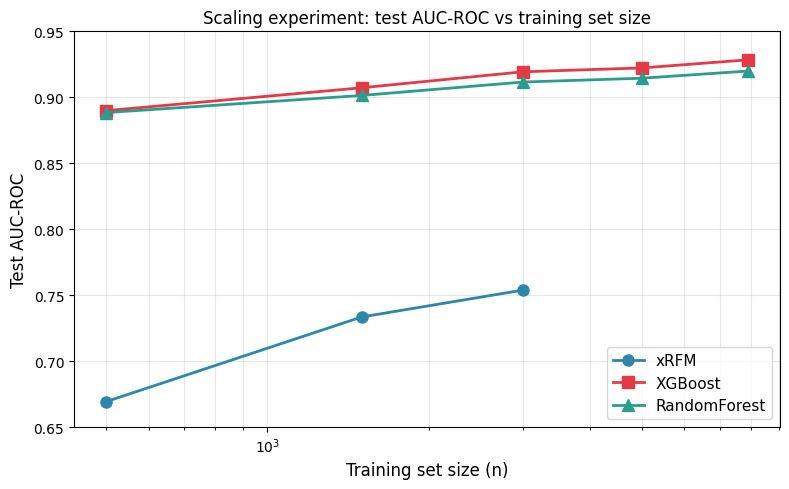

Saved: results/figures/scaling_performance.png


In [6]:
MODEL_ORDER = ['xRFM', 'XGBoost', 'RandomForest']
MODEL_COLORS = {'xRFM': '#2E86AB', 'XGBoost': '#E63946', 'RandomForest': '#2A9D8F'}
MODEL_MARKERS = {'xRFM': 'o', 'XGBoost': 's', 'RandomForest': '^'}

fig, ax = plt.subplots(figsize=(8, 5))

for model in MODEL_ORDER:
    sub = scaling_df[scaling_df['model'] == model].sort_values('n_train')
    ax.plot(sub['n_train'], sub['AUC-ROC'],
            marker=MODEL_MARKERS[model], color=MODEL_COLORS[model],
            linewidth=2, markersize=8, label=model)

ax.set_xlabel('Training set size (n)', fontsize=12)
ax.set_ylabel('Test AUC-ROC', fontsize=12)
ax.set_title('Scaling experiment: test AUC-ROC vs training set size',
             fontsize=12)
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0.65, 0.95)

plt.tight_layout()
plt.savefig('results/figures/scaling_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/scaling_performance.png")

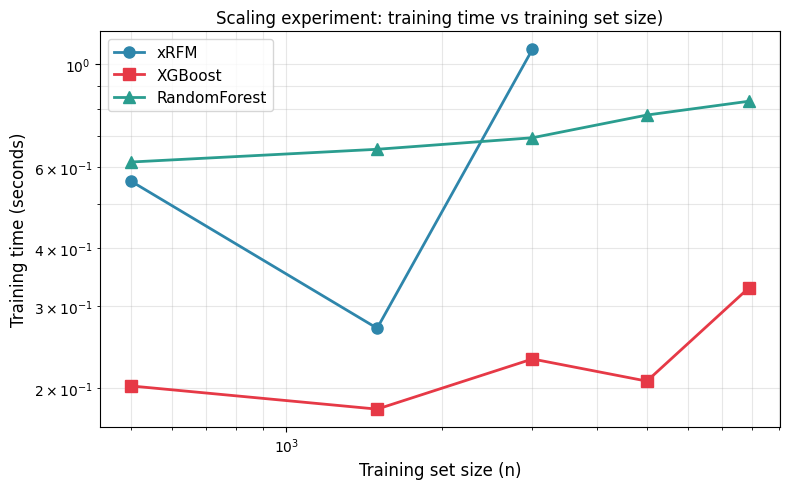

Saved: results/figures/scaling_training_time.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for model in MODEL_ORDER:
    sub = scaling_df[scaling_df['model'] == model].sort_values('n_train')
    ax.plot(sub['n_train'], sub['train_time_s'],
            marker=MODEL_MARKERS[model], color=MODEL_COLORS[model],
            linewidth=2, markersize=8, label=model)

ax.set_xlabel('Training set size (n)', fontsize=12)
ax.set_ylabel('Training time (seconds)', fontsize=12)
ax.set_title('Scaling experiment: training time vs training set size)',
             fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('results/figures/scaling_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/scaling_training_time.png")